# Предсказания ВР с использованием Deep Learning

[Coloab](https://colab.research.google.com/github/MVRonkin/TimeSeriesCourse/blob/main/2026/WS/08%20-%20%D0%BF%D1%80%D0%B5%D0%B4%D1%81%D0%BA%D0%B0%D0%B7%D0%B0%D0%BD%D0%B8%D0%B5%20%D0%B7%D0%BD%D0%B0%D1%87%D0%B5%D0%BD%D0%B8%D0%B9%20%D0%92%D0%A0%20%D1%81%20DL.ipynb)

In [14]:
import ray
import torch
import pytorch_lightning as pl

In [15]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Fri_Jun_14_16:44:19_Pacific_Daylight_Time_2024
Cuda compilation tools, release 12.6, V12.6.20
Build cuda_12.6.r12.6/compiler.34431801_0


C:\Users\MVRonkin\miniconda3\envs\ts\Lib\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedWriter name=3>
  res = process_handler(cmd, _system_body)
C:\Users\MVRonkin\miniconda3\envs\ts\Lib\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedReader name=4>
  res = process_handler(cmd, _system_body)
C:\Users\MVRonkin\miniconda3\envs\ts\Lib\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedReader name=5>
  res = process_handler(cmd, _system_body)


In [16]:
import torch

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

if torch.cuda.is_available():
    print(f"CUDA version in PyTorch: {torch.version.cuda}")  # Версия, с которой собран PyTorch
    print(f"cuDNN version: {torch.backends.cudnn.version()}")
    print(f"GPU Name: {torch.cuda.get_device_name(0)}")
    print(f"Compute Capability: {torch.cuda.get_arch_list()}")
else:
    print("CUDA is NOT available in PyTorch")

PyTorch version: 2.10.0+cu128
CUDA available: True
CUDA version in PyTorch: 12.8
cuDNN version: 91002
GPU Name: NVIDIA GeForce RTX 5060 Ti
Compute Capability: ['sm_70', 'sm_75', 'sm_80', 'sm_86', 'sm_90', 'sm_100', 'sm_120']


In [17]:
import os
if not os.path.exists('utilits4tsc'):
    !git clone --depth 1 https://github.com/MVRonkin/TimeSeriesCourse.git temp_repo
    !mv temp_repo/2026/WS/utilits4tsc .

In [18]:
from utilits4tsc import *
from IPython.display import display, Markdown
display(Markdown(generate_toc(max_lvl=2)))

## Содержание
* [Предсказания ВР с использованием Deep Learning](#предсказания-вр-с-использованием-deep-learning)
  * [Основные материалы к работе](#основные-материалы-к-работе)
  * [Обзор DL моделей](#обзор-dl-моделей)
  * [Знакомство с объектом `NeuralForecast`](#знакомство-с-объектом-neuralforecast)
  * [Продвинутая настройка моделей NeuralForecast](#продвинутая-настройка-моделей-neuralforecast)

## Основные материалы к работе

### Темы в работе

|раздел | [Nixtla](https://nixtlaverse.nixtla.io/neuralforecsat/) / [GitHub](https://github.com/Nixtla/statsforecast/blob/main/nbs/docs/)| [FPPPY](https://otexts.com/fpppy/)|
|-------|-----------------------|------|
|NeuralForecast| [GitHub](https://github.com/Nixtla/neuralforecast/blob/main/nbs/docs/getting-started/introduction.ipynb)/[Nixtla](https://nixtlaverse.nixtla.io/neuralforecast/docs/getting-started/introduction.html) | [Chapter 14](https://otexts.com/fpppy/nbs/14-neural-networks.html) |
|Foundation models| [GitHub](https://github.com/Nixtla/nixtla/tree/main/nbs/docs)/[Nixtla](https://www.nixtla.io/docs/introduction/introduction) | [Chapter 15](https://otexts.com/fpppy/nbs/15-foundation-models.html) |


### Дополнительня литература

* [amazing-nvda-forecasting-neuralforecast](https://www.kaggle.com/code/guslovesmath/amazing-nvda-forecasting-neuralforecast)
* [unpacking-neuralforecasts-design-principles](https://readmedium.com/unpacking-neuralforecasts-design-principles-to-streamline-advanced-timeseries-model-raining-a-90f771c5e629)

### Сопутствующие библиотеки
* [uni2ts](https://github.com/SalesforceAIResearch/uni2ts)
* [Large-Time-Series-Model](https://github.com/thuml/Large-Time-Series-Model)
* [Time-Series-Library](https://github.com/thuml/Time-Series-Library)
* [pytorch-forecasting](https://github.com/sktime/pytorch-forecasting)
* [gluon-ts](https://github.com/jgasthaus/gluon-ts)

### Импорт

#### Общие функции

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [20]:
import warnings
warnings.filterwarnings("ignore", ".*does not have many workers.*")

In [21]:
from sklearn.linear_model import Ridge, LinearRegression, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.metrics import mean_absolute_error
from sklearn.preprocessing import StandardScaler

In [22]:
import warnings
warnings.filterwarnings('once')

In [23]:
from functools import partial

In [24]:
from utilsforecast.plotting import plot_series
from utilsforecast.evaluation import evaluate
from utilsforecast.losses import *

#### NeuralForecast


В данной работе мы изучим возможности использования библиотеки [`NeuralForecast`](https://nixtlaverse.nixtla.io/neuralforecast) для решения задачи предсказания ВР с использованием методов глубокого обучения нейронных сетей. В библиотеке `NeuralForecast` используются современные DL-модели  как мощные модели, например  `TFT` и `NHITS`позволяют обрабатывать сложные нелинейные зависимости в данных временных рядов, так и классические модели типа `LSTM`. Приемуществами [`NeuralForecast`](https://nixtlaverse.nixtla.io/neuralforecast/examples/statsmlneuralmethods.html) является

Ключевые особенности [NeuralForecast](https://nixtlaverse.nixtla.io/neuralforecast/examples/statsmlneuralmethods.html#neuralforecast) включают:
* Широкая коллекция глобальных моделей. Реализация `MLP`, `LSTM`, `NBEATS`, `NHITS`, `Informer`, `PatchTST` [и других](https://nixtlaverse.nixtla.io/neuralforecast/models.html) моделей из коробки. При этом ряд моделей имеют режимы автонастройки. Также фреймворк позволет сравнительно просто тестировать сразу наборы моделей.
* Простой и интуитивно понятный интерфейс "SKLearn-like", позволяющий проводить обучение, прогнозирование и бэктестирование различных моделей всего в нескольких строках кода.
* Поддержка `GPU`-ускорения для повышения скорости вычислений.
* фреймворк построен на основе фреймворков [`PyTorch`](https://pytorch.org/get-started/locally/) и [`PyTorch Lightning`](https://pypi.org/project/pytorch-lightning/).

In [25]:
import neuralforecast

### Причины выбора DL

 Как правило  модели прогнозирования, не основанные на нейронной сети, (`ARIMA`, экспоненциальное сглаживание и т.д.)  являются __локальными моделями__, они обучаются на одном временном ряду для прогнозирования будущего именно этого ряда. Это позволяет строить прогнозы для кажого ВР отдельно, используя тщательную настройку. Такой подход позволяет достигать наилучших результатов, если модель соотвествует (описывает) ВР достаточно точно. Иногда удется также описать и __глобальную модель__ для нескольких ВР или ВР с управляющими факторами.  Однако, модель может быть построена не восвсех случаях. В ряде задач временные ряды не позволяют быть описаными, например в силу слишьком большой длительности или количества переменных. В этих случях часто отдельные участки ВР требуют уникальное описание (не удается описать всю систему единым образом). В таком случае, ВР могут быть характеризованы как большие данные. 

 Большенство моделей прогнозирования с на основе данных - являются моделями __[глобального прогнозирования](https://unit8.com/resources/training-forecasting-models/)__. Это означает, что эти модели могут быть обучены на нескольких рядах и могут прогнозировать будущие значения любых временных рядов, даже рядов, которые не содержатся в обучающем наборе.

Модели на основе глубоких нейронных сетей имеют особые [приемущества](https://github.com/thuml/Time-Series-Library?tab=readme-ov-file#leaderboard-for-time-series-analysis) в задачах предсказания продолжительного контекста, данных с пропусками и аномалиями.
Возможность обучать одну модель на основе нескольких рядов данных является очень важной особенностью, поскольку обычно модели глубокого обучения лучше всего проявляют себя, когда они обучаются на большом объеме данных. Это позволяет им сопоставлять закономерности в потенциально большом количестве связанных временных рядов. Например, модель `N-BEATS` обеспечивает превосходные результаты прогнозирования при обучении на десятках тысяч временных рядов в `M4 competition` (хорошо известном соревновании по прогнозированию).

 Отметим следующие приемущества использования глубокого обучения нейронных сетей в задачах предсказания временных рядов: 
<!-- * НС могут обрабатывать последовательные данные различной длины, эффективно улавливая долгосрочные зависимости и временные закономерности.
* НС учитывают неравномерно распределенные временные интервалы а также пропуски и выборсы во временных рядах.
* НС адаптируются к различным задачам прогнозирования с входными и выходными последовательностями различного соотношения длины.
* НС позволяют работать с данными в любых отношениях (напр. многокомпонентные, иерархические ряды, ряды с ковариатами и т.д.) 

Однако, Глубокая нейронная сеть. -->

*	Нет необходимости в статистической гипотезе или конкретной форме модели.
*	Может аппроксимировать любую функцию с пропущенными данными, аномалиями и другими нерегулярными шаблонами.
*	Позволяют работать с огромными многомерными рядами данных со сложной взаимосвязью поведения между данными.
*	Автоматически извлекают и обрабатывают сложные признаки и отношения между ними.
*	Для сложных и многомерных данных в большом количестве модели, управляемые данными, могут обеспечить лучшую производительность.

НО

*	Требуется тщательная настройка гиперпараметров.
*	Часто требуется ансамбль сетей для получения высокой точности.
*	Тяжело перетренировать.
*	Трудно достичь сопоставимой точности с подходом на основе модели для относительно простых рядов.



### Загрузка данных

#### Данные с шагом 1 день

In [26]:
df= pd.read_csv(os.path.join( "utilits4tsc",
            "OPDS_DE_EDA.csv"),
    parse_dates=["time"],
    index_col="time"
)
df.head(1)



ts = ['Consumption','Wind',	'Solar']
base_cols = ['unique_id', 'ds', 'y']
exog_cols = ['temperature','radiation_direct_horizontal']

y = df.resample('D').agg({
    'Consumption': 'sum',
    'Wind': 'sum',
    'Solar': 'sum',
    'temperature': 'mean',
    'radiation_direct_horizontal': 'mean'
}).ffill().bfill() + 1e-8

y = y.iloc[1:-2]


date_index = y.index
panel_list = [
    pd.DataFrame({
        'ds': date_index,
        'y': y[t].values,
        'unique_id': t,
        # Добавляем внешние переменные из y:
        'temperature': y['temperature'].values,
        'radiation_direct_horizontal': y['radiation_direct_horizontal'].values
    }) 
    for t in ts
]

panel_df = pd.concat(panel_list, ignore_index=True)
panel_df = panel_df[base_cols + exog_cols] # Теперь это сработает

panel_df.sample(5)

FREQ = y.index.freq

SEASON = 52*7

# FH = int(0.42 * y.shape[0])



#### Split: train/val/test

In [27]:
test_size = SEASON   # 
val_size  = SEASON   # 

df_test  = panel_df[base_cols].groupby("unique_id").tail(test_size)
df_train_val = panel_df[base_cols].drop(df_test.index).reset_index(drop=True)
# df_test_exdogs  = panel_df[base_cols+exog_cols].groupby("unique_id").tail(FH)
# df_train_exdogs = panel_df[base_cols+exog_cols].drop(df_test.index).reset_index(drop=True)

df_val   = df_train_val.groupby("unique_id").tail(val_size)
df_train = df_train_val.drop(df_val.index).reset_index(drop=True)

#### Визуализация

In [28]:
df_ = df_train.rename(columns={'y': 'y_train'}).merge(
    df_val.rename(columns={'y': 'y_val'}), on=['unique_id', 'ds'], how='outer'
    ).merge(
    df_test.rename(columns={'y': 'y_test'}), on=['unique_id', 'ds'], how='outer'
    ).merge(
    panel_df[base_cols], on=['unique_id', 'ds'], how='left'
    )

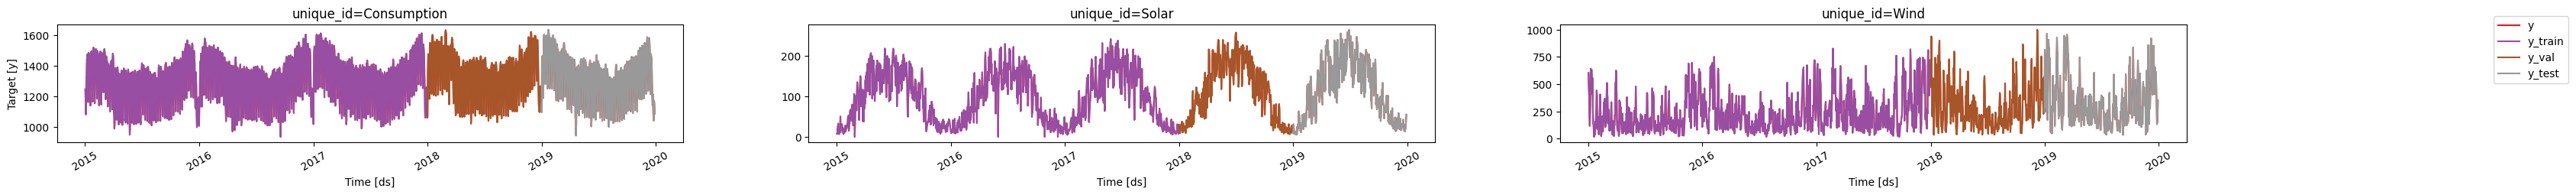

In [29]:
plot_series_v2(forecasts_df= df_,  palette='Set1', n_cols = 3)

#### Метрики

In [30]:
metric_map = {
    'mase': partial(mase, seasonality=SEASON),
    'mae': mae,
    'rmse': rmse,
    'smape': smape,
    # 'CPSR':scaled_crps,
    # 'CI':coverage,
    # 'SQL':partial(scaled_quantile_loss, seasonality=SEASON),
}
metrics = list(metric_map.values())
metric_names = list(metric_map.keys())

## Обзор DL моделей

В данном примере будут рассмотрены несоклько архитектур нейронных сетей для предсказания значений временных рядов. 
Рассмотрим следующие архитектуры.


<details> <summary> LSTM </summary>

* Архитектура __[`LSTM`](https://nixtlaverse.nixtla.io/neuralforecast/models.nhits.html)__. Архитектура основывается на рекуррентных ячейках с длинной и короткой функцией "паямяти"([`LSTM`](https://arxiv.org/abs/1402.1128)).
В данном фреймворке используется архитектура типа энкодер-декодер, где энкодер состоит из нескольких `LSTM` слоев тогда как декодер состоит из полносявзных слоев. Предсказания осуществляются итерационно. 
Напомним, что струдктура одной [`LSTM`](https://www.bioinf.jku.at/publications/older/2604.pdf) предсавляет собой набор латентных связей (т.н. [gates](https://d2l.ai/chapter_recurrent-modern/lstm.html)). Среди них есть связи для продолжительных зависимостей - продолжительного контекста и связей для отслеживания краковременных изменений. Связи сохраняют и контролируют поток градиентов в длинных последовательностях. Это позволяет сети более эффективно улавливать долгосрочные зависимости и значительно повышает ее способность к обучению на последовательных данных. `LSTM` имеет три гейта (вход, забывание и выход) и отлично справляется с улавливанием долгосрочных зависимостей.
В какой то степери долговременный контекст соответствует тренду и цикличности, в то время как крактовременный контекст соответствует сезонности. В литературе представлено несколько модификций `LSTM`, структура типичной ячейки может [быть представлена](https://colah.github.io/posts/2015-08-Understanding-LSTMs/) как\
<img src="https://nixtla.github.io/neuralforecast1/imgs_models/lstm.png" width="500px">\
<img src="https://www.deeplearningwizard.com/deep_learning/practical_pytorch/images/rnn2n.png" width="500px">\                 
> Напоним что рекуррентные ячейки ([`RNN`](https://onlinelibrary.wiley.com/doiabs/10.1207/s15516709cog1)) явлются в некоторой степени реализацией нелинейного марковского проецсса. Ячейка может быть выражена в виде `state-space` выражения как
> $$  \begin{cases}
   h_{t} = \mathrm{Activation}(x_{t} W^{\intercal}_{ih} + b_{ih}  +  h_{t-1} W^{\intercal}_{hh} + b_{hh}), 
   \\
  \mathbf{y}_{[t+1]}=\mathrm{Activation}(h_{t}W^{out}_{yh} + b_{yh} ).
 \end{cases} $$
> В фреймворке `Neuralforecast` архитектура рекуррентный энкодер-полносвязный декодер представляется [следующим образом](https://nixtla.github.io/neuralforecast1/models.rnn.html):
> $$  \begin{cases}
   h_{t} = \mathrm{Activation}(x_{t} W^{\intercal}_{ih} + b_{ih}  +  h_{t-1} W^{\intercal}_{hh} + b_{hh}), 
   \\
  \mathbf{y}_{[t+1:t+H]}=\mathrm{MLP}(h_{t}).
 \end{cases} $$
> Также отметим, что в фреймворке `Neuralforecast` реализуются модифицированная `LSTM` ячейка - [`GRU`](https://nixtla.github.io/neuralforecast1/models.gru.html). В данной ячейке используется комбинация долговременного и кратковременного контекста.\
> <img src="https://nixtla.github.io/neuralforecast1/imgs_models/gru.png" width="500px">\
> Также в фреймворке может быть найдена архитектура расширенной `RNN` ячейки с использованием некоторого аналога пулинга - т.н. расширение ([`dialation`](https://arxiv.org/abs/1710.02224)). Данный прием позволяет охватить длинные контексты с наименьшим число параметров. Рост значения `dialation` можно рассматривать как низкочастотную фильтацию.\
> <img src="https://nixtla.github.io/neuralforecast1/imgs_models/dilated_rnn.png" width="500px">\
> Также одной из наболее успешных модификаций рекуррентного подхода можно назвать [`DeepAR`](https://www.sciencedirect.com/science/article/pii/S0169207019301888). Данная модель также может быть найдена в [`Neuralforecast`](https://nixtlaverse.nixtla.io/neuralforecast/models.deepar.html). Идея модели заключается в порождении вероятностного прогнозы на основе оптимизированной глубокой авторегрессионной рекуррентной нейронной сети. То есть каждое следующее значение порождается из предсказанного распределения (аналог вероятностного прогназирования). \
> <img src="https://ars.els-cdn.com/content/image/1-s2.0-S0169207019301888-gr3_lrg.jpg" width="500px">\
> Рекуррентные архитектуры имеют ряд приемуществ, такие как простота (низкая вычислительня сложность) и возможность работы с длинными контекстами.
> Однако [у рекурретных архитектур](https://encord.com/blog/time-series-predictions-with-recurrent-neural-networks/)  есть ограничения, такие как проблема исчезающего или взрывающегося градиента, которая влияет на их способность улавливать долгосрочные зависимости, поскольку РНС могут быть развернуты очень далеко назад в этом Ограничения памяти также могут ограничить их производительность при работе с очень длинными последовательностями. Хотя такие методы, как `LSTM` и `GRU`, смягчают некоторые проблемы, другие продвинутые архитектуры, такие как трансформаторы, могут превосходить RNN в некоторых сложных сценариях временных рядов, что требует тщательного выбора модели.
> * __[Проблема исчезающего градиента](https://encord.com/blog/time-series-predictions-with-recurrent-neural-networks/)__ - это проблема, которая влияет на обучение глубоких нейронных сетей, включая рекуррентные нейронные сети (РНС). Она возникает, когда градиенты, указывающие направление и величину обновлений весов сети в процессе обучения, становятся очень маленькими по мере распространения в обратном направлении по слоям. Это явление препятствует способности РНС к изучению дальних зависимостей и может привести к медленному или неэффективному обучению. \
> __Проблема исчезающего градиента__ особенно проблематична в последовательностях, где информация должна запоминаться или распространяться в течение длительного времени, что влияет на способность сети улавливать важные закономерности. Для борьбы с проблемой исчезающего градиента, препятствующей эффективному обучению нейронных сетей, было разработано несколько стратегий. Такие методы, как правильная инициализация веса, нормализация партии, обрезание градиента, пропуск соединений и планирование скорости обучения, играют ключевую роль в стабилизации градиентного потока и предотвращении его безвременной гибели.

<!-- >Архитектура DeepAR получает распределение прогнозов с помощью выборки по методу Монте-Карло с использованием марковской цепи на панельных данных с использованием перекрестного обучения. При этом условная вероятность задается как: $$ -->

<details> <summary> NBEATS </summary>
    
* Архитектура __[`NBEATS`](https://arxiv.org/abs/1905.10437)__ ([Neural Basis Expansion Analysis](https://nixtlaverse.nixtla.io/neuralforecast/models.nbeats.html)) представляет собой глубокую нейронную архитектуру на основе `MLP` с обратными и прямыми остаточными связями. Архитектура `NBEATS`   [одна из наиболее успешных](https://forecastegy.com/posts/multiple-time-series-forecasting-nbeats-python/) остается одной из наболее успешных не реккуррентных архитектур для предсказания ВР [на среднем горзионте предсказаний](https://www.researchgate.net/publication/351512864_N-BEATS_neural_network_for_mid-term_electricity_load_forecasting). По существу архитектура представляет собой набор блоков, каждый из которых имеет два выхода: предсказание в перед и предсказание назад.\
<img src="https://www.researchgate.net/profile/Boris-Oreshkin/publication/351512864/figure/fig1/AS:1023454975365121@1621022089657/N-BEATS-block-diagram_W640.jpg" width="500px">\
Прямое предсказание очевидно предсказывает будущее значения, тогда как обратное предсказание выступает ограничителем порстранства предсказаний.
Модель предсказывает $h$ значений для входного окна (ретроспектива <tt>Lookback Period</tt>) размером $n\cdot h$, где $n, h$ - гиперпараметры.  Слои `NBEATS` соеденены т.н. принципом <tt>Doubly Residual Stacking Of Blocks</tt>. Где входной велчиной для каждого следующего блока является разность предсказаных значений предыдущего блока и его входных значений. Таким образом создается аналог бустинга. Последний блок называется <tt>Stack Backcast output</tt>. Выходное предсказание формируется как сумма результатов для каждого из блока<tt> Stack Forecast Output</tt>.\
<img src=https://www.researchgate.net/profile/Boris-Oreshkin/publication/351512864/figure/fig1/AS:1023454975365121@1621022089657/N-BEATS-block-diagram_W640.jpg" width="200px"> \
Отметим, что архитектура [`NBEATS`](https://arxiv.org/abs/1905.10437) имеет два варианта:
    * (1) в [интерпретируемой конфигурации](https://www.kaggle.com/code/gatandubuc/forecast-with-n-beats-interpretable-model)
    *  `NBEATS` последовательно проецирует сигнал на полиномы и гармонический базис для изучения компонентов тренда и сезонности;
    * (2) в общей конфигурации она заменяет полиномиальный и гармонический базис на базис идентичности и увеличивает глубину сети.
    * Анализ расширения нейронного базиса с учетом экзогенных факторов ([`NBEATSx`](https://arxiv.org/abs/2104.05522)) включает в себя проекции на экзогенные временные переменные, доступные на момент прогнозирования.\
[Интерпретируемая архитектура](https://nixtlaverse.nixtla.io/neuralforecast/models.nbeats.html) рекомендуется для работы с ограниченными данными, поскольку она упорядочивает  прогнозы с помощью проекций на гармоническую и трендовую базы, что хорошо подходит для большинства задач прогнозирования.\
Для получения [тренда и сезонности](https://arxiv.org/pdf/1905.10437) в интерпретируемой архитектуре авторы предлагают замену последнего слоя на полиномиальную аппроксимацию (тренд) и разложение в ряд Фурье ($sin$ и $cos$ соответственно). [Примеры nen](https://github.com/philipperemy/n-beats/blob/master/nbeats_pytorch/model.py) того как это выглядит показаны ниже.
|<img src="https://miro.medium.com/v2/resize:fit:1286/format:webp/1*Jznia_xjulaUbpNLATh_wg.png" width="300px">|<img src="https://miro.medium.com/v2/resize:fit:1286/format:webp/1*ERhjDwMuDkhktYisCsFoQQ.png" width="300px"> |<img src="https://miro.medium.com/v2/resize:fit:1286/format:webp/1*pqJxiTLGVSf_OZqTrHYT1A.png" width="300px">|
|---|---|---|
|полный блок `N-BEATS`|блок тренда `N-BEATS` |блок периода `N-BEATS`|   

<!-- https://nixtla.github.io/neuralforecast/imgs_models/nbeats.png -->

<details> <summary> NHITS </summary>

* Архитектура __[`NHITS`](https://arxiv.org/abs/2201.12886)__ - Нейронная иерархической интерполяции временных рядов ([Neural Hierarchical Interpolation for Time Series, NHITS](https://nixtlaverse.nixtla.io/neuralforecast/models.nhits.html)) является расширением идеи [`NBEATS`](https://arxiv.org/abs/1905.10437) для предсказаний на длинные горизонты. Указывается, что при прогнозе на длинные горизонты оснвные две проблемы это волатильность и вычислительная сложность. Модель [`NHITS`](https://github.com/cchallu/n-hits) решает эти проблемы путем  много-масштабного семплинга входа и выхода и иерархической интерполяции. Семплинг [реализуется](https://unit8co.github.io/darts/generated_api/darts.models.forecasting.nhits.html) за счет операции `MaxPooling`. Указанные операции позволяют методу [`NHITS`](https://github.com/cchallu/n-hits) собирать свои прогнозы последовательно, выборочно выделяя компоненты с различными частотами и масштабами при декомпозиции входного сигнала и при синтезе прогноза. Ожидается что семплинг будет некоторым аналогом разложения ВР на компоненты. Таким образом в отличии от [`NBEATS`](https://arxiv.org/abs/1905.10437) принцип бустинга заменяется на принцип декомпозиции на некоторый аналог эмпирических мод. Однако, для восстоновления исходной размерности после обработки семплированных мод используется интерполяция. Интерполяция может быть как линейной, так и кубической. <img src="https://github.com/cchallu/n-hits/raw/main/images/nhits-arch.png" width="500px">
> Отметим, что [подобно](https://unit8co.github.io/darts/generated_api/darts.models.forecasting.nhits.html) `NBEATS`, в дополнение к одномерной версии, представленной в статье, эта реализация также поддерживает многомерные ряды (и ковариаты), предсавляя входные данные модели до одномерного ряда и преобразуя выходные данные в тензор соответствующих размеров. Кроме того, модель также поддерживает создание вероятностных прогнозов (путем указания параметра правдоподобия).
> [Особенностью архитектуры](https://www.datasciencewithmarco.com/blog/all-about-n-hits-the-latest-breakthrough-in-time-series-forecasting) является использование передискретизации (макс-пулинга) как метода выделения все более низко-частотных компонент. <img src="https://cdn-images-1.medium.com/max/800/1*_1Q15mryT59_WEWuhghATw.png" width="500px">
>
<img src="https://ai2-s2-public.s3.amazonaws.com/figures/2017-08-08/3667179eca208e4b609089c5dc25387294272007/2-Figure1-1.png" width="500px">
https://www.catalyzex.com/paper/arxiv:2210.02186

<details> <summary> Vanilla Transformer </summary>
    
* Трансформер __([Vanilla Transformer](https://arxiv.org/pdf/2012.07436))__ представляет собой сочитание [нескольких интуиций](https://huggingface.co/blog/time-series-transformers) в отношении [временных рядов](https://nixtlaverse.nixtla.io/neuralforecast/models.vanillatransformer.html). \
 \* Начнем с того, что использование архитектуры кодировщик-декодировщик (`encoder`-`decoder`) интуитивно позволяет генерировать последовательности предсказаний (с заданным горизонтом) в подход `sequence2sequence`. При этом мы можем, задав некоторый тип распределения, породить выборку из него, чтобы получить прогнозы до желаемого горизонта предсказания. Это известно как жадная выборка/поиск предсказаний, \
 \* Во-вторых, архитеткуры типа трансформатор помогает обучаться на продолжительных  временных рядах, которые могут содержать тысячи временных точек и соразмерные горизонты прогнозирования. Ввод в модель всей истории временного ряда за один раз может быть нецелесообразен из-за ограничений по времени и памяти механизма внимания.\
      <tt> Отметим, что таким образом, можно рассмотреть некоторое подходящее контекстное окно и выбрать это окно и последующее окно с размером длины предсказания из обучающих данных при формироании батчей для стохастического градиентного спуска (`SGD`). При этом окно с размером контекста может быть передано кодировщику, а окно предсказания - декодеру с каузальной маской. __Казуальная маска__ означает, что декодер может просматривать только предыдущие временные шаги при обучении следующему значению.</tt>\
 \* Еще одно преимущество архитектур `Transformer` по сравнению с другими архитектурами заключается в том, что мы можем включать отсутствующие значения (пропуски, несинхронность встречаются во временных рядах) в качестве дополнительной маски для кодера или декодера и продолжать обучение, не прибегая к их заполнению или фильтрации. Такая маска будет называться `attention_mask`.  Кроме того, поскольку `Transformer` может перестраиваться или узнавать ложные корреляции гораздо легче, чем другие методы.\
 \* При этом недостатком оригинальной (`Vanilla`) архитектуры `Transformer` является ограничение размеров контекстного окна и окна предсказания из-за квадратичных требований к вычислениям и памяти.\
 <img src="https://www.researchgate.net/publication/373287556/figure/fig1/AS:11431281211958098@1702516201905/The-informer-model-for-time-series-prediction_W640.jpg" width="500px">


<details> <summary> informer </summary>

>* [Отметим](https://arxiv.org/pdf/2012.07436), что в случае многомерных отображений ВР учет полной размерности данных  может оказаться вычислительно сложным, поэтому  прибегают к некоторой аппроксимации распределения, проще всего моделируя каждую компоненту как независимое распределение из того же семейства, или некоторую низкоранговую аппроксимацию и т.д.\
В первую очередь вычислительная сложность обсуловлена операциями внимания. Этот слой требует $O(T^2)$ операций, где $T$ - размер окна ВР. Эта проблема особенно актуальна при длинных горизонтах прогнозирования `Long sequence time-series forecasting` __`(LSTF problem)`__. Одно из решений этой проблемы известно как `ProbSparse` идея этого метода в использовании эффекта __разряженности моделей__. В архитектуре __[`informer`](https://arxiv.org/pdf/2012.07436)__ для снижения чила операций до $O(T \cdot log T)$. \
Vanilla self attention vs `ProbSparse` attention  иллюстрация из работы [Autoformer paper](https://wuhaixu2016.github.io/pdf/NeurIPS2021_Autoformer.pdf)\
<img src="https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/blog/informer/informer_full_vs_sparse_attention.png" width="700px">\
Таким образом общая архитектура  [`informer`](https://github.com/zhouhaoyi/Informer2020) будет [иметь вид](https://www.mdpi.com/2073-8994/15/4/951)
<img src="https://www.mdpi.com/symmetry/symmetry-15-00951/article_deploy/html/images/symmetry-15-00951-g001.png" width="500px">\
В дополнение к `ProbSparse` архитектура [`informer`](https://huggingface.co/docs/transformers/en/model_doc/informer) может использоваться дистиляция слоя `attention`. Этим число параметров энкодера урезается в 2 раза. Также в данной архитектуре используется генеративное предсказание выходной последовательности целиком. Это упрощает и ускоряет процесс работы модели.

<details> <summary> autoformer </summary>

>* Также одна из интересных последних архитектур __[`autoformer`](https://arxiv.org/pdf/2106.13008)__ представляет идею того, что помимо боков трансформеров следует проводить разложение моделйе ВР на стандартные компоненты (тренд, сезонность, остаток) при помощи `Decomposition Layer`. Данная модель также предлагает альтернативу архитектуре слоя внимания - `auto-correlation mechanism`.  Этот подход по меньшей мере снижает вычислительную сложность по сравнению с вниманием до нескольких $T \log{T}$ [(если операция реализуется через быстрое преобразование Фурье)](https://huggingface.co/blog/autoformer). По существу модель возвращает архитектурные решения, разработанные для текстов в архитектурах-трансформерах к их более нативному (интерпретируемому) виду для архитектур моделей временных рядов.\
<img src="https://huggingface.co/datasets/huggingface/documentation-images/resolve/main/blog/148_autoformer/autoformer_architecture.png" width="500px">\
Ааналогичные решения с декомпозицией были применены в архитектурах [`DLinear`](https://arxiv.org/pdf/2205.13504) и [`FEDformer`](https://arxiv.org/pdf/2201.12740).

<details> <summary> Temporal Fusion Transformer </summary>

* Модель __Temporal Fusion Transformer [`TFT`](https://arxiv.org/abs/1912.09363)__ представляет собой [гибридную архитектуру](https://github.com/google-research/google-research/tree/master/tft), объединяющую `LSTM`-кодирование временных рядов и интерпретируемость слоев внимания трансформатора. Прогнозирование базируется как на основном  ВР (авторегрессионная переменная), так и для ковариатов к ним. В данной архитектуре можно провести разделение ковариатов на статические (постоянные для временного ряда), будущие ковариаты (known, известные заранее для всей истории и будущего) и истонические (наблюдаемые, известные только для исторических данных). Также для архитектуры важно являются ли входные переменные категориальными и непрерывными.\
Переменные встраиваются в высокоразмерное пространство путем обучения вектора встраивания. Встраивания категориальных переменных изучаются в классическом смысле встраивания дискретных значений. Для каждой непрерывной переменной модель обучается одному вектору, который затем масштабируется для дальнейшей обработки. \
Следующим шагом является фильтрация переменных с помощью сети выбора переменных (`Variable Selection Network`, `VSN`). Эта сеть присваивает веса входам в соответствии с их значимостью для предсказания.  Статические переменные используются в качестве контекста для выбора других переменных и в качестве начального состояния `LSTM`-кодировщиков. \
После кодирования переменные передаются в многоголовые слои внимания (декодер), которые формируют окончательное предсказание. Вся архитектура переплетена остаточными связями с механизмами стробирования, которые позволяют архитектуре адаптироваться к различным задачам, пропуская некоторые ее части. \
Блоки архитектуры сопровждаются ячейкми блокировки (Gated residual network, GRN), которые позволяют архитектуре адаптироваться к различным проблемам, пропуская некоторые ее части. \
[Таким образом](https://nixtlaverse.nixtla.io/neuralforecast/models.tft.html) `TFT` сочетает в себе слои стробирования, рекуррентный энкодер `LSTM` и многоголовые слои внимания для декодера с многоступенчатой стратегией прогнозирования. Модель позволяет предсказывать доверительные интервалы для нескольких будущих значений временных рядов. 
<img src="https://github.com/NVIDIA/DeepLearningExamples/raw/master/PyTorch/Forecasting/TFT/TFT_architecture.PNG" width="700px">
<img src="https://developer-blogs.nvidia.com/wp-content/uploads/2022/02/Time-Series-Forecast_Pic-3-768x533.png" width="500px">
>Отметим, что в данной реализации отличие от эталонной в том, что решает проблему недостающих данных, которая часто встречается в производственных наборах данных, либо маскируя их значения в матрицах внимания, либо встраивая их как особое значение в латентное пространство.\
>В целях объяснимости, главы слоев самовнимания имеют общие матрицы значений. Это позволяет интерпретировать самовнимание как ансамбль моделей, предсказывающих различные временные паттерны по одному и тому же набору признаков.\
> Другая характеристика, помогающая понять модель, - активация VSN, которая говорит нам, насколько релевантна данный признак для предсказания.\
>Также отметим, что в общем смысле могут быть и другие модификации архитектур внимания. вот некоторое их [summary](https://seunghan96.github.io/ts/ts56/):
><img src="https://seunghan96.github.io/assets/img/ts/img305.png" width="500px">

<details> <summary> DLinear </summary>
    
* Некоторой модификацией идей внимания, трансформеров и других подходов является ахритектура [`DLinear`](https://arxiv.org/pdf/2205.13504). Авторы ставят вопрос о необходимости использования трансформеров для прямого предсказания для длинном горизонте. Предполагается что эту идеию можно заменить любой нелинейной операцией. Наиболее интерпретируемая из таких операций с точки зрения авторов - это разложение временного ряда на тренд (плюс цикличность) и сезонность и их независимая фильтрация. Идея блока архитектуры может быть проиллюстрирована [следующим образом](https://github.com/vivva/DLinear?tab=readme-ov-file):
<img src="https://github.com/vivva/DLinear/raw/main/pics/DLinear.png" width="800px">
>В качестве мотивайии авторы работы [указывают следующую](https://arxiv.org/pdf/2205.13504). "Основная идея трансформера заключается в многоголовый механизме самовнимания, который обладает способностью извлекать семантические корреляции между элементами в длинной последовательности (например, слов в текстах или двухмерных локациях на изображениях). Однако самовнимание в определенной степени инвариантно к перестановкам и «антипорядку». Хотя использование различных методов позиционного кодирования позволяет сохранить некоторую информацию об упорядочивании, все же неизбежны временные потери информации после применения самовнимания поверх них. Обычно это не является серьезной проблемой для семантически насыщенных приложений, таких как NLP.  Например, семантический смысл предложения в значительной степени сохраняется, даже если мы переставляем некоторые
слова в нем. Однако при анализе данных временных рядов семантика в числовых данных обычно отсутствует и нас в основном интересует моделирование временных изменений среди непрерывного набора точек. То есть порядок значений играет наиболее важную роль. Следовательно, мы
ставится следующий интригующий вопрос: Действительно ли трансформеры эффективны для долгосрочного прогнозирования временных рядов? Более того, хотя существующие решения проблем долгосрочного прогноза (LTSF) на основе трансформера демонстрируют значительное повышение точности прогнозирования по сравнению с традиционными методами, в экспериментах все сравниваемые (не трансформеры) базовые модели используют авторегрессионный или итерационный многошаговый (IMS) прогноз, который, как известно, страдает от значительного эффекта накопления ошибок для задачи LTSF.


 

>Отметим, что в целом могут быть и дополнительные блоки, позволяющие оптимизировать архитектуры. Например использование [нормализации Временных рядов](https://openreview.net/pdf?id=cGDAkQo1C0p).

## Знакомство с объектом `NeuralForecast`

### Выбор и настройка моделей

Загрузим несколько тестовых моделей. В том числе рекурретную архитектуру `encoder-decoder` и архитектуру `NHITS`. Для Архитектур будут указаны общие параметры:
* `h` - горизонт предсказания;
* `max_steps` - число эпох обучения;
* `default_root_dir` - путь для сохранения промежуточных результатов.

Корме того архитектура [`LSTM`](https://nixtlaverse.nixtla.io/neuralforecast/models.lstm.html), имеющая `LSTM` `encoder`, и  `MLP` `decoder`.  которая  задана своими:
* `encoder_hidden_size` - число параметров слоев энкодера (по умолчанию 2 слоя)
* `decoder_hidden_size` - число параметров слоев декодера (по умолчанию 2 слоя)

Архитектура [`NHITS`](https://nixtlaverse.nixtla.io/neuralforecast/models.nhits.html)

In [31]:
from neuralforecast import NeuralForecast
from neuralforecast.models import LSTM, NHITS, DLinear, Informer
from ray import tune
from neuralforecast.auto import AutoNHITS

Обратите внимание на особенность отображения пути! `log_path`

In [32]:
from pathlib import Path
home_dir = Path('~').expanduser()

In [33]:
horizon = test_size//2
log_path = str(home_dir)

models = [
        LSTM(h=horizon,                    # Forecast horizon 
             input_size = 3*horizon,
             max_steps=50,                # Number of steps to train
             scaler_type='standard',       # Type of scaler to normalize data
             encoder_hidden_size=128,       # Defines the size of the hidden state of the LSTM
             decoder_hidden_size=128,       # Defines the number of hidden units of each layer of the MLP decoder  
             default_root_dir=log_path),       
        NHITS(h=horizon,                   # Forecast horizon
              input_size= horizon,      # Length of input sequence
              max_steps=50,               # Number of steps to train
              n_freq_downsample=[1, 1, 1],  # Downsampling factors for each stack output
              default_root_dir=log_path),
        DLinear(h=horizon,                 # Forecasting horizon
                input_size=2*horizon,           # Input size
                max_steps=50,               # Number of training iterations
                moving_avg_window = 2*(horizon//2) + 1,
                val_check_steps=10,          # Compute validation loss every 100 steps
                default_root_dir=log_path), # Stop training if validation loss does not improve
          ]

Seed set to 1
Seed set to 1
Seed set to 1


### Запустим модель на обучение

#### Fit

In [34]:
nf = NeuralForecast(models=models, freq=FREQ)
nf.fit(df=df_train, val_size = val_size)

C:\Users\MVRonkin\miniconda3\envs\ts\Lib\site-packages\neuralforecast\common\_base_model.py:345: UserWarning: val_check_steps is greater than max_steps, setting val_check_steps to max_steps.
  warnings.warn(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
You are using a CUDA device ('NVIDIA GeForce RTX 5060 Ti') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/docs/stable/generated/torch.set_float32_matmul_precision.html#torch.set_float32_matmul_precision
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name            | Type          | Params | Mode  | FLOPs
-----------

Sanity Checking: |                                                                               | 0/? [00:00<…

C:\Users\MVRonkin\miniconda3\envs\ts\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\MVRonkin\miniconda3\envs\ts\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
C:\Users\MVRonkin\miniconda3\envs\ts\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
C:\Users\MVRonkin\miniconda3\envs\ts\Lib\site-packages\pytorch_lightning\loops\fit_loop.py:317: The number of training batches (1) is smaller than the lo

Training: |                                                                                      | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

...

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

`Trainer.fit` stopped: `max_steps=50` reached.


#### Predict

In [35]:
y_hat = nf.predict(df_train_val)

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
C:\Users\MVRonkin\miniconda3\envs\ts\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\MVRonkin\miniconda3\envs\ts\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


Predicting: |                                                                                    | 0/? [00:00<…

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |                                                                                    | 0/? [00:00<…

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |                                                                                    | 0/? [00:00<…

C:\Users\MVRonkin\miniconda3\envs\ts\Lib\site-packages\neuralforecast\core.py:209: FutureWarning: In a future version the predictions will have the id as a column. You can set the `NIXTLA_ID_AS_COL` environment variable to adopt the new behavior and to suppress this warning.
  warnings.warn(


Обратите внимание модели работают в Direct Multioutput  режиме - выход размером с заданный в моделях горизонт

In [36]:
y_hat=fix_forecast_format(y_hat)


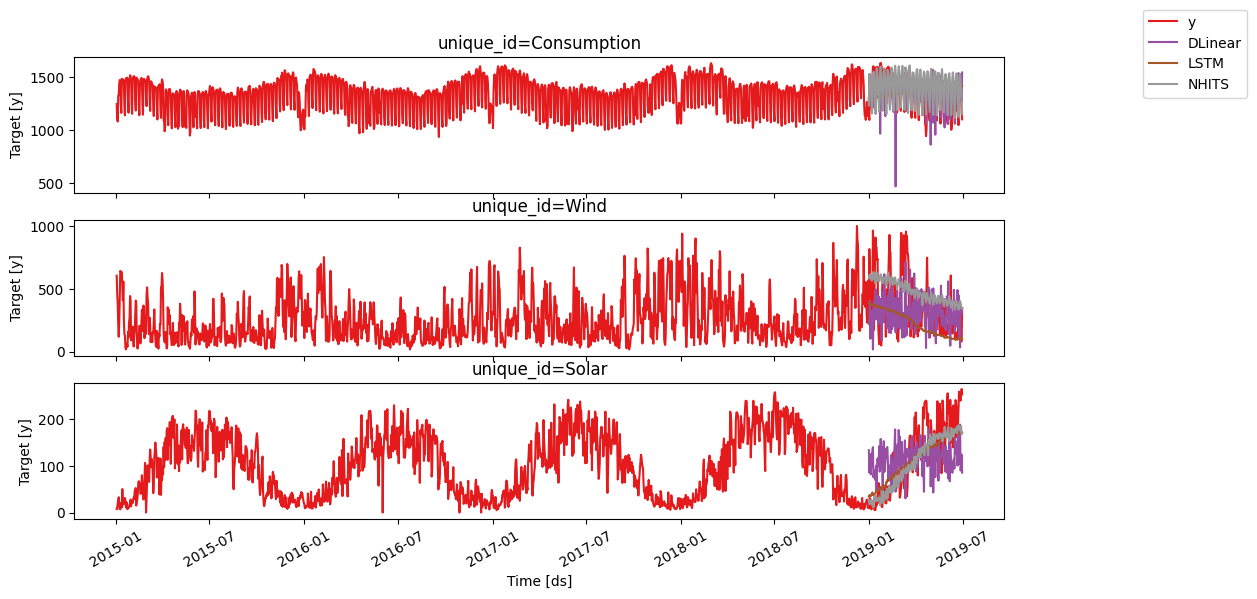

In [37]:
evaluate_and_plot(df_train_val,
                  df_test,
                  forecasts_or_eval = y_hat,
                  metrics = metrics)

#### LongHorzion Forecasting

LongHorzion - это n_step_ahed forecasting, то есть предсказание в несклько шагов. Проще всего его реализовать как кросс валидацию, где шаг равер горизонту (без пересечения) и без повторного обучения

В некоторых версиях нельзя использовать рекуррентные модели с шагом больше 1

In [38]:
nf.models =nf.models[1:]
nf.models

[NHITS, DLinear]

In [39]:
n_steps = (test_size)//horizon

forecasts_df = nf.cross_validation(
        df=panel_df,
        val_size = val_size,
        step_size= horizon,
        test_size= test_size,
        n_windows=None,
        refit = False
    ).drop(columns = ['cutoff'])


C:\Users\MVRonkin\miniconda3\envs\ts\Lib\site-packages\neuralforecast\common\_base_model.py:345: UserWarning: val_check_steps is greater than max_steps, setting val_check_steps to max_steps.
  warnings.warn(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | loss         | MAE           | 0      | train | 0    
1 | padder_train | ConstantPad1d | 0      | train | 0    
2 | scaler       | TemporalNorm  | 0      | train | 0    
3 | blocks       | ModuleList    | 3.1 M  | train | 0    
---------------------------------------------------------------
3.1 M     Trainable p

Sanity Checking: |                                                                               | 0/? [00:00<…

C:\Users\MVRonkin\miniconda3\envs\ts\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\MVRonkin\miniconda3\envs\ts\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
C:\Users\MVRonkin\miniconda3\envs\ts\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
C:\Users\MVRonkin\miniconda3\envs\ts\Lib\site-packages\pytorch_lightning\loops\fit_loop.py:317: The number of training batches (1) is smaller than the lo

Training: |                                                                                      | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

...

Validation: |                                                                                    | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

`Trainer.fit` stopped: `max_steps=50` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |                                                                                    | 0/? [00:00<…

C:\Users\MVRonkin\miniconda3\envs\ts\Lib\site-packages\neuralforecast\core.py:209: FutureWarning: In a future version the predictions will have the id as a column. You can set the `NIXTLA_ID_AS_COL` environment variable to adopt the new behavior and to suppress this warning.
  warnings.warn(


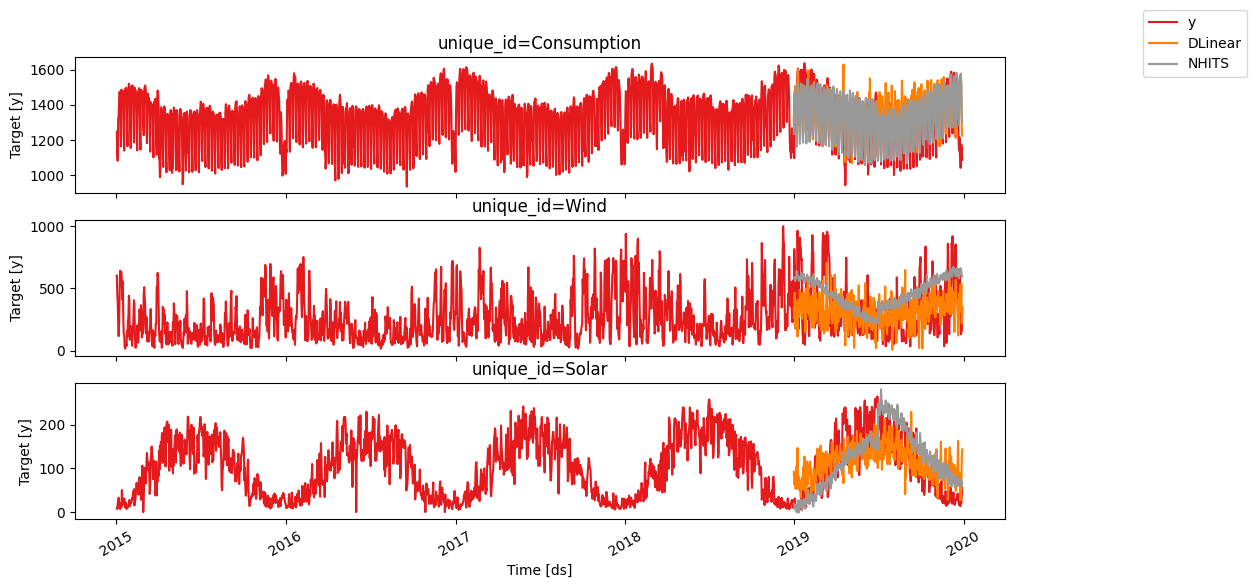

In [40]:
# plot_series_v2(df_train_val,forecasts_df = forecasts_df)
evaluate_and_plot(df_train_val,
                  df_test,
                  forecasts_or_eval = fix_forecast_format(forecasts_df),
                  metrics = metrics)

#### Упражнения
1. Провести несколько экспериментов по настройке гиперпарамертров моделей и сравнить точность

## Продвинутая настройка моделей NeuralForecast

### выбор loss функции

In [41]:
from neuralforecast.losses.pytorch import MSE, RMSE, MAE, SMAPE

loss = SMAPE()  # или RMSE()

In [42]:
models = [
        LSTM(h=horizon,                    # Forecast horizon 
             loss = loss,
             input_size = 3*horizon,
             max_steps=50,                # Number of steps to train
             scaler_type='standard',       # Type of scaler to normalize data
             encoder_hidden_size=128,       # Defines the size of the hidden state of the LSTM
             decoder_hidden_size=128,       # Defines the number of hidden units of each layer of the MLP decoder  
             default_root_dir=log_path),       
        NHITS(h=horizon,                   # Forecast horizon
              loss = loss,
              input_size= horizon,      # Length of input sequence
              max_steps=50,               # Number of steps to train
              n_freq_downsample=[1, 1, 1],  # Downsampling factors for each stack output
              default_root_dir=log_path),
        DLinear(h=horizon,                 # Forecasting horizon
                input_size=2*horizon,           # Input size
                loss = loss,
                max_steps=50,               # Number of training iterations
                moving_avg_window = 2*(horizon//2) + 1,
                val_check_steps=10,          # Compute validation loss every 100 steps
                default_root_dir=log_path), # Stop training if validation loss does not improve
          ]

Seed set to 1
Seed set to 1
Seed set to 1


C:\Users\MVRonkin\miniconda3\envs\ts\Lib\site-packages\neuralforecast\common\_base_model.py:345: UserWarning: val_check_steps is greater than max_steps, setting val_check_steps to max_steps.
  warnings.warn(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name            | Type          | Params | Mode  | FLOPs
------------------------------------------------------------------
0 | loss            | SMAPE         | 0      | train | 0    
1 | padder          | ConstantPad1d | 0      | train | 0    
2 | scaler          | TemporalNorm  | 0      | train | 0    
3 | hist_encoder    | LSTM          | 199 K  | train | 0    
4 | context_adapter | Linear        | 234 K  | train | 0    
5 | ml

Sanity Checking: |                                                                               | 0/? [00:00<…

C:\Users\MVRonkin\miniconda3\envs\ts\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\MVRonkin\miniconda3\envs\ts\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
C:\Users\MVRonkin\miniconda3\envs\ts\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
C:\Users\MVRonkin\miniconda3\envs\ts\Lib\site-packages\pytorch_lightning\loops\fit_loop.py:317: The number of training batches (1) is smaller than the lo

Training: |                                                                                      | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

...

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |                                                                                    | 0/? [00:00<…

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |                                                                                    | 0/? [00:00<…

C:\Users\MVRonkin\miniconda3\envs\ts\Lib\site-packages\neuralforecast\core.py:209: FutureWarning: In a future version the predictions will have the id as a column. You can set the `NIXTLA_ID_AS_COL` environment variable to adopt the new behavior and to suppress this warning.
  warnings.warn(


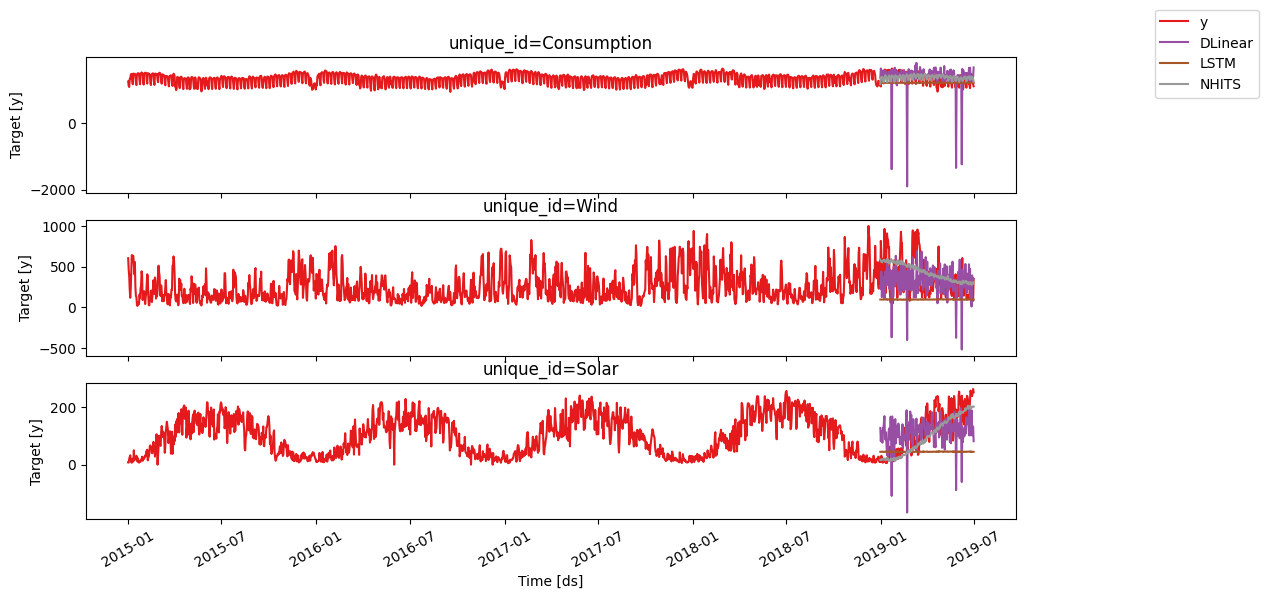

In [43]:
nf = NeuralForecast(models=models, freq=FREQ)
nf.fit(df=df_train, val_size = val_size)
y_hat = nf.predict(df_train_val)
y_hat=fix_forecast_format(y_hat)
evaluate_and_plot(df_train_val,
                  df_test,
                  forecasts_or_eval = y_hat,
                  metrics = metrics)

#### Упражнение
1. Проверить как выбор лосс-функции влияет на резултат прогноза дляразных алгоритмов

### Вероятностное прогнозирование через выбор loss-функции 

Вероятностное прогнозирование является естественным ответом на вопрос о количественной оценке неопределенности будущего целевой переменной. Задача требует моделирования следующего условного прогнозного распределения: 
$$\mathbb{P}(\mathbf{y}_{t+1:t+H} \;|\; \mathbf{y}_{:t})$$
Для этого используем ` multi quantile loss function (MQLoss)`
$$ \mathrm{MQLoss}(y_{\tau}, [\hat{y}^{(q1)}_{\tau},\hat{y}^{(q2)}_{\tau},\dots,\hat{y}^{(Q)}_{\tau}]) = \frac{1}{H} \sum_{q} \mathrm{QL}(y_{\tau}, \hat{y}^{(q)}_{\tau}) $$

In [44]:
from neuralforecast.losses.pytorch import MQLoss

In [45]:
horizon = test_size
levels = [80, 90]
loss=MQLoss(level=levels)

In [46]:
models = [ LSTM(h=horizon,                    # Forecast horizon 
               max_steps=10,                # Number of steps to train
               scaler_type='standard',       # Type of scaler to normalize data
               encoder_hidden_size=128,       # Defines the size of the hidden state of the LSTM
               decoder_hidden_size=128,       # Defines the number of hidden units of each layer of the MLP decoder 
               loss=loss, 
               default_root_dir=log_path),      
          NHITS(h=horizon,                   # Forecast horizon
                input_size= horizon,      # Length of input sequence
                max_steps=10,               # Number of steps to train
                loss=loss,
                n_freq_downsample=[1, 1, 1],  # Downsampling factors for each stack output
                default_root_dir=log_path) ,
           DLinear(h=horizon,                 # Forecasting horizon
                input_size=2*horizon,           # Input size
                max_steps=10,               # Number of training iterations
                moving_avg_window = 2*(horizon//2) + 1,
                val_check_steps=10,          # Compute validation loss every 100 steps
                loss=loss,   
                default_root_dir=log_path), # Stop training if validation loss does not improve
          ]

Seed set to 1
Seed set to 1
Seed set to 1


C:\Users\MVRonkin\miniconda3\envs\ts\Lib\site-packages\neuralforecast\common\_base_model.py:345: UserWarning: val_check_steps is greater than max_steps, setting val_check_steps to max_steps.
  warnings.warn(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name            | Type          | Params | Mode  | FLOPs
------------------------------------------------------------------
0 | loss            | MQLoss        | 5      | train | 0    
1 | padder          | ConstantPad1d | 0      | train | 0    
2 | scaler          | TemporalNorm  | 0      | train | 0    
3 | hist_encoder    | LSTM          | 199 K  | train | 0    
4 | context_adapter | Linear        | 469 K  | train | 0    
5 | ml

Sanity Checking: |                                                                               | 0/? [00:00<…

C:\Users\MVRonkin\miniconda3\envs\ts\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\MVRonkin\miniconda3\envs\ts\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
C:\Users\MVRonkin\miniconda3\envs\ts\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
C:\Users\MVRonkin\miniconda3\envs\ts\Lib\site-packages\pytorch_lightning\loops\fit_loop.py:317: The number of training batches (1) is smaller than the lo

Training: |                                                                                      | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

...

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |                                                                                    | 0/? [00:00<…

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |                                                                                    | 0/? [00:00<…

C:\Users\MVRonkin\miniconda3\envs\ts\Lib\site-packages\neuralforecast\core.py:209: FutureWarning: In a future version the predictions will have the id as a column. You can set the `NIXTLA_ID_AS_COL` environment variable to adopt the new behavior and to suppress this warning.
  warnings.warn(


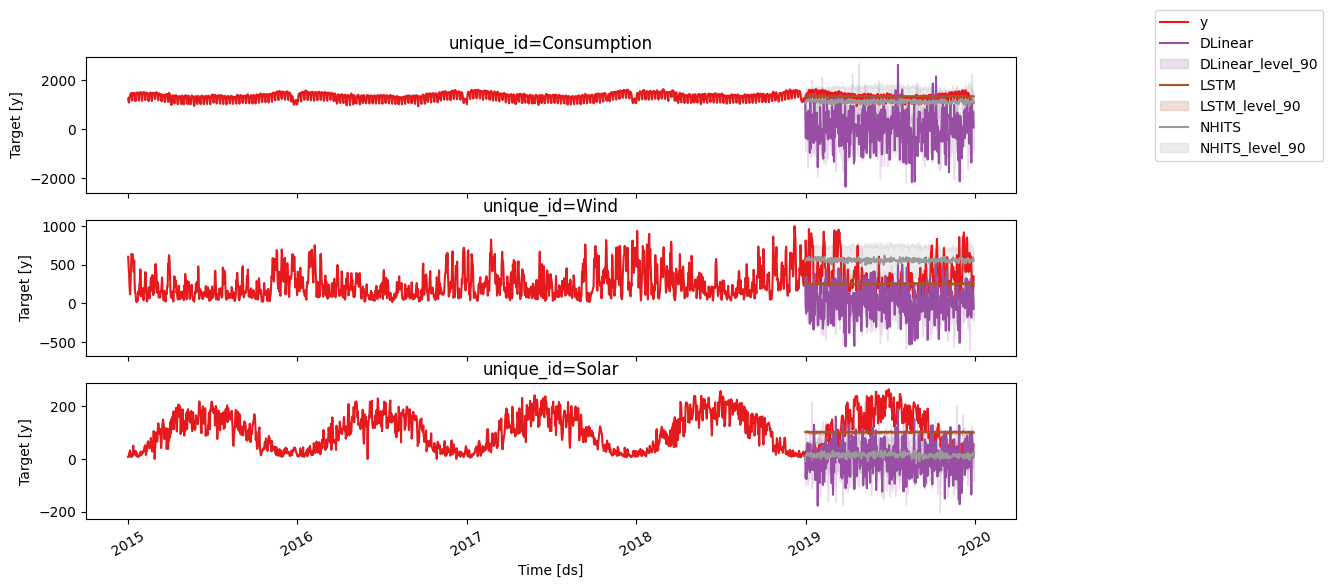

In [47]:
nf = NeuralForecast(models=models, freq=FREQ)
nf.fit(df=df_train, val_size = val_size)
y_hat = nf.predict(df_train_val)
y_hat=fix_forecast_format(y_hat, strip_suffixes=['-median'] )
evaluate_and_plot(df_train_val,
                  df_test,
                  forecasts_or_eval = y_hat,
                  levels=levels[-1:],
                  metrics = metrics)

### Собственная функция потерь

In [48]:
class HuberLoss(torch.nn.Module):
    def __init__(self, delta: float = 1.0):
        super(HuberLoss, self).__init__()
        self.outputsize_multiplier = 1
        self.output_names = ['']
        self.is_distribution_output = False
        self.delta = delta  # Порог переключения между квадратичной и линейной частью

    def domain_map(self, y_hat: torch.Tensor):
        return y_hat.squeeze(-1)

    def __call__(self, y: torch.Tensor, y_hat: torch.Tensor,
                 mask: Union[torch.Tensor, None] = None):
    
        if mask is None:
            mask = torch.ones_like(y)
        error = y - y_hat
        abs_error = torch.abs(error)
        quadratic = 0.5 * error ** 2
        linear = self.delta * (abs_error - 0.5 * self.delta)
        loss = torch.where(abs_error <= self.delta, quadratic, linear)
        loss = loss * mask
        loss = loss.mean()
        return loss

In [49]:

loss = HuberLoss()

In [50]:
models = [ LSTM(h=horizon,                    # Forecast horizon 
               max_steps=10,                # Number of steps to train
               scaler_type='standard',       # Type of scaler to normalize data
               encoder_hidden_size=128,       # Defines the size of the hidden state of the LSTM
               decoder_hidden_size=128,       # Defines the number of hidden units of each layer of the MLP decoder 
               loss=loss, 
               default_root_dir=log_path),      
          NHITS(h=horizon,                   # Forecast horizon
                input_size= horizon,      # Length of input sequence
                max_steps=10,               # Number of steps to train
                loss=loss,
                n_freq_downsample=[1, 1, 1],  # Downsampling factors for each stack output
                default_root_dir=log_path) ,
           DLinear(h=horizon,                 # Forecasting horizon
                input_size=2*horizon,           # Input size
                max_steps=10,               # Number of training iterations
                moving_avg_window = 2*(horizon//2) + 1,
                val_check_steps=10,          # Compute validation loss every 100 steps
                loss=loss,   
                default_root_dir=log_path), # Stop training if validation loss does not improve
          ]

Seed set to 1
Seed set to 1
Seed set to 1


C:\Users\MVRonkin\miniconda3\envs\ts\Lib\site-packages\neuralforecast\common\_base_model.py:345: UserWarning: val_check_steps is greater than max_steps, setting val_check_steps to max_steps.
  warnings.warn(
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]

  | Name            | Type          | Params | Mode  | FLOPs
------------------------------------------------------------------
0 | loss            | HuberLoss     | 0      | train | 0    
1 | padder          | ConstantPad1d | 0      | train | 0    
2 | scaler          | TemporalNorm  | 0      | train | 0    
3 | hist_encoder    | LSTM          | 199 K  | train | 0    
4 | context_adapter | Linear        | 469 K  | train | 0    
5 | ml

Sanity Checking: |                                                                               | 0/? [00:00<…

C:\Users\MVRonkin\miniconda3\envs\ts\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.
C:\Users\MVRonkin\miniconda3\envs\ts\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
C:\Users\MVRonkin\miniconda3\envs\ts\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.
C:\Users\MVRonkin\miniconda3\envs\ts\Lib\site-packages\pytorch_lightning\loops\fit_loop.py:317: The number of training batches (1) is smaller than the lo

Training: |                                                                                      | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

...

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |                                                                                    | 0/? [00:00<…

GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]


Predicting: |                                                                                    | 0/? [00:00<…

C:\Users\MVRonkin\miniconda3\envs\ts\Lib\site-packages\neuralforecast\core.py:209: FutureWarning: In a future version the predictions will have the id as a column. You can set the `NIXTLA_ID_AS_COL` environment variable to adopt the new behavior and to suppress this warning.
  warnings.warn(


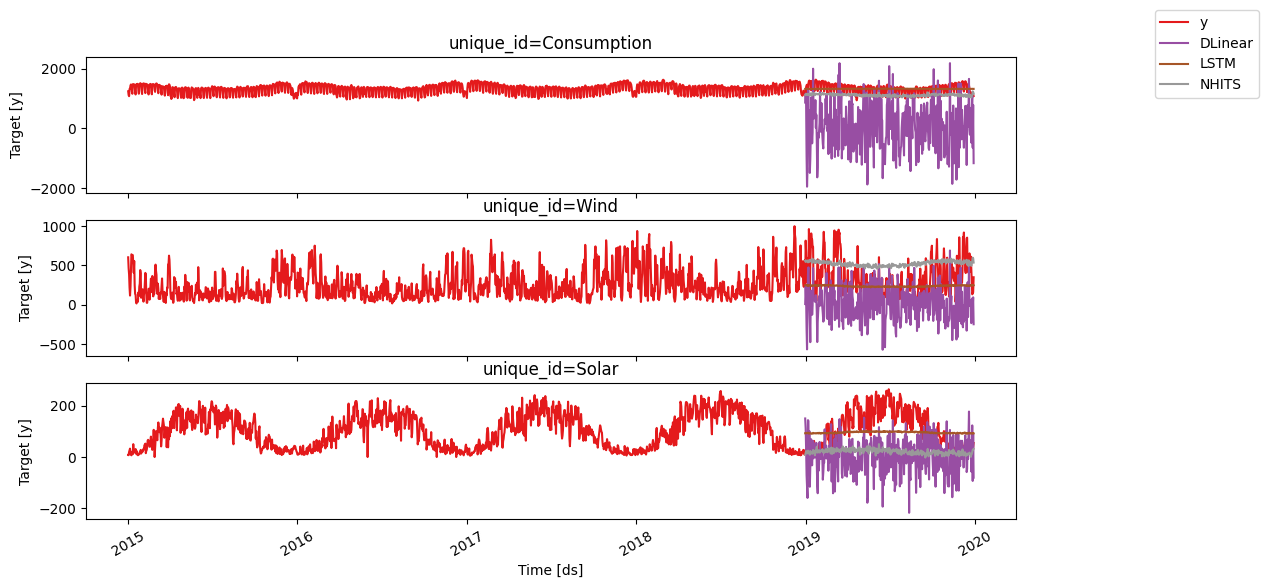

In [51]:
nf = NeuralForecast(models=models, freq=FREQ)
nf.fit(df=df_train, val_size = val_size)
y_hat = nf.predict(df_train_val)
y_hat=fix_forecast_format(y_hat, strip_suffixes=['-median'] )
evaluate_and_plot(df_train_val,
                  df_test,
                  forecasts_or_eval = y_hat,
                  # levels=levels[-1:],
                  metrics = metrics)

#### Упражнение 
1. предлагается сделать квантильный лосс самостоятельно:
   ```python
   torch.max((self.quantile - 1) * error, self.quantile * error)

https://colab.research.google.com/github/Nixtla/neuralforecast/blob/main/nbs/examples/LongHorizon_with_Transformers.ipynb#scrollTo=BDbGGkTax8it

In [55]:
from neuralforecast.losses.pytorch import DistributionLoss

In [85]:
from ray import tune
from ray.tune.search.hyperopt import HyperOptSearch

In [58]:
torch.set_float32_matmul_precision('high')

In [68]:
nhits_config = {
       "learning_rate": tune.choice([1e-3]),                                     # Initial Learning rate
       "max_steps": tune.choice([100]),                                         # Number of SGD steps
       "input_size": tune.choice([horizon, 1.5*horizon]),                                 # input_size = multiplier * horizon
       "windows_batch_size": tune.choice([256]),                                 # Number of windows in batch
       "n_pool_kernel_size": tune.choice([[2, 2, 2], [16, 8, 1]]),               # MaxPool's Kernelsize
       "n_freq_downsample": tune.choice([[168, 24, 1], [24, 12, 1], [1, 1, 1]]), # Interpolation expressivity ratios
       "activation": tune.choice(['ReLU']),                                      # Type of non-linear activation
       "n_blocks":  tune.choice([[1, 1, 1]]),                                    # Blocks per each 3 stacks
       "mlp_units":  tune.choice([[[512, 512], [512, 512], [512, 512]]]),        # 2 512-Layers per block for each stack
       "interpolation_mode": tune.choice(['linear']),                            # Type of multi-step interpolation
       "random_seed": tune.randint(1, 10),
       "scaler_type": tune.choice(['robust']),
       "val_check_steps": tune.choice([100]),
       "start_padding_enabled":True,  # ← ключевой параметр
    }

In [69]:
models = [AutoNHITS(h=horizon,
                    loss=DistributionLoss(distribution='StudentT', level=[90]), 
                    config=nhits_config,
                    search_alg=HyperOptSearch(),
                    backend='ray',
                    num_samples=5)]

In [75]:
nf = NeuralForecast(models=models, freq=FREQ)
# nf.fit(df=df_train, val_size = val_size)
Y_hat_df = nf.cross_validation(df=panel_df, 
                               val_size=val_size,
                               test_size=test_size, 
                               n_windows=None)

(_train_tune pid=16376) C:\Users\MVRonkin\miniconda3\envs\ts\Lib\site-packages\ray\tune\integration\pytorch_lightning.py:198: `ray.tune.integration.pytorch_lightning.TuneReportCallback` is deprecated. Use `ray.tune.integration.pytorch_lightning.TuneReportCheckpointCallback` instead.
(_train_tune pid=16376) Seed set to 9
(_train_tune pid=16376) GPU available: True (cuda), used: True
(_train_tune pid=16376) TPU available: False, using: 0 TPU cores
(_train_tune pid=16376) 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
(_train_tune pid=16376) You are using a CUDA device ('NVIDIA GeForce RTX 5060 Ti') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precision for performance. For more details, read https://pytorch.org/do

Epoch 99: 100%|██████████| 1/1 [00:00<00:00, 142.86it/s, v_num=0, train_loss_step=5.630, train_loss_epoch=5.630]
Validation: |          | 0/? [00:00<?, ?it/s]
Validation: |          | 0/? [00:00<?, ?it/s]
Epoch 99: 100%|██████████| 1/1 [00:00<00:00, 47.62it/s, v_num=0, train_loss_step=5.630, train_loss_epoch=5.630, valid_loss=5.730]


(_train_tune pid=16376) `Trainer.fit` stopped: `max_steps=100` reached.
(_train_tune pid=5432) C:\Users\MVRonkin\miniconda3\envs\ts\Lib\site-packages\ray\tune\integration\pytorch_lightning.py:198: `ray.tune.integration.pytorch_lightning.TuneReportCallback` is deprecated. Use `ray.tune.integration.pytorch_lightning.TuneReportCheckpointCallback` instead.
(_train_tune pid=5432) Seed set to 9
(_train_tune pid=5432) GPU available: True (cuda), used: True
(_train_tune pid=5432) TPU available: False, using: 0 TPU cores
(_train_tune pid=5432) 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
(_train_tune pid=5432) You are using a CUDA device ('NVIDIA GeForce RTX 5060 Ti') that has Tensor Cores. To properly utilize them, you should set `torch.set_float32_matmul_precision('medium' | 'high')` which will trade-off precis

Epoch 95:   0%|          | 0/1 [00:00<?, ?it/s, v_num=0, train_loss_step=5.700, train_loss_epoch=5.700]         


(_train_tune pid=5432) `Trainer.fit` stopped: `max_steps=100` reached.


...

Training: |                                                                                      | 0/? [00:00<…

Validation: |                                                                                    | 0/? [00:00<…

`Trainer.fit` stopped: `max_steps=100` reached.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
C:\Users\MVRonkin\miniconda3\envs\ts\Lib\site-packages\pytorch_lightning\trainer\connectors\data_connector.py:434: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=19` in the `DataLoader` to improve performance.


Predicting: |                                                                                    | 0/? [00:00<…

C:\Users\MVRonkin\miniconda3\envs\ts\Lib\site-packages\neuralforecast\core.py:209: FutureWarning: In a future version the predictions will have the id as a column. You can set the `NIXTLA_ID_AS_COL` environment variable to adopt the new behavior and to suppress this warning.
  warnings.warn(


In [76]:
y_hat = fix_forecast_format(Y_hat_df,strip_suffixes=['-median'])

Внимание! После удаления суффиксов появились дубликаты колонок.


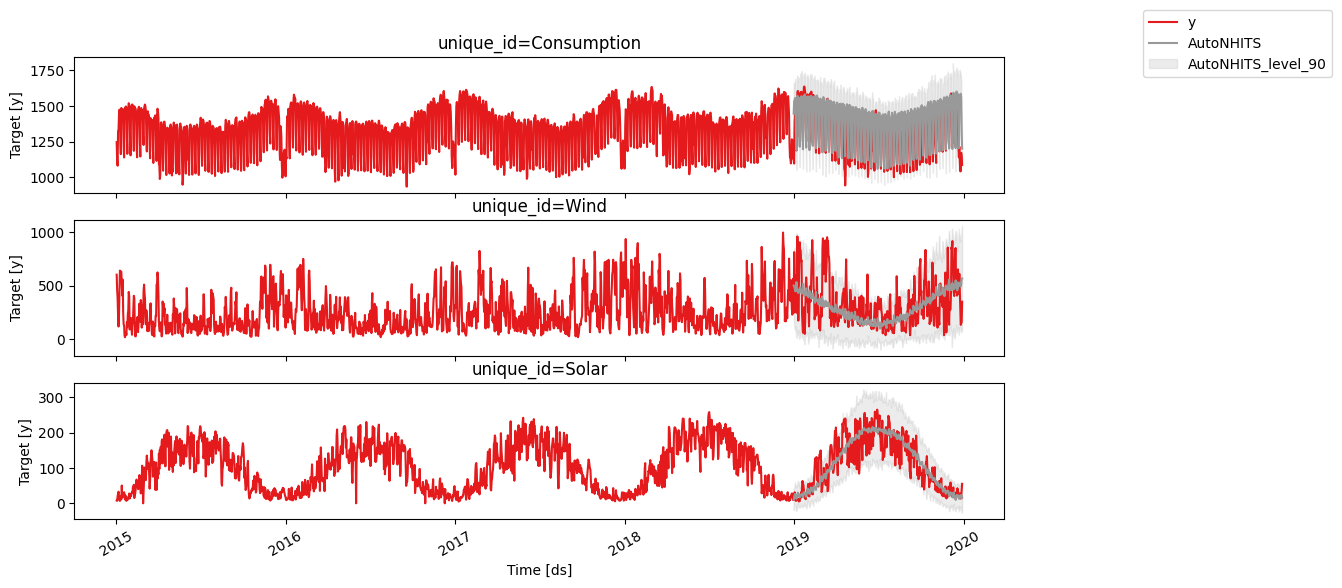

In [78]:
evaluate_and_plot(df_train_val,
                  df_test,
                  forecasts_or_eval = y_hat,
                  levels=levels[-1:],
                  metrics = metrics)

In [82]:
results = nf.models[0].results.get_dataframe()
results

,loss,train_loss,timestamp,checkpoint_dir_name,done,training_iteration,trial_id,date,time_this_iter_s,time_total_s,...,config/mlp_units,config/interpolation_mode,config/random_seed,config/scaler_type,config/val_check_steps,config/start_padding_enabled,config/h,config/loss,config/valid_loss,logdir
0,5.733131,5.634380,1773062257,None,False,1,53a11_00000,2026-03-09_18-17-37,1.726216,1.726216,...,"[[512, 512], [512, 512], [512, 512]]",linear,9,robust,100,True,364,DistributionLoss(),DistributionLoss(),53a11_00000
1,5.735912,5.631263,1773062264,None,False,1,53a11_00001,2026-03-09_18-17-44,1.937301,1.937301,...,"[[512, 512], [512, 512], [512, 512]]",linear,9,robust,100,True,364,DistributionLoss(),DistributionLoss(),53a11_00001
2,5.812119,5.671041,1773062272,None,False,1,53a11_00002,2026-03-09_18-17-52,1.724900,1.724900,...,"[[512, 512], [512, 512], [512, 512]]",linear,4,robust,100,True,364,DistributionLoss(),DistributionLoss(),53a11_00002
3,5.759785,5.611351,1773062280,None,False,1,53a11_00003,2026-03-09_18-18-00,1.745610,1.745610,...,"[[512, 512], [512, 512], [512, 512]]",linear,4,robust,100,True,364,DistributionLoss(),DistributionLoss(),53a11_00003


#### Упражнения
1. Провести настройку параметров для всех указанных алгоритмов и сравнить результаты
   

## Foundation Models

In [88]:
# !pip install uni2ts

In [89]:
from gluonts.dataset.pandas import PandasDataset
from gluonts.dataset.split import split
from uni2ts.model.moirai import MoiraiForecast, MoiraiModule

### Moirai

<img src="https://otexts.com/fpppy/img/moirai_archi.png">

In [ ]:
import pandas as pd
import numpy as np
import os

# Импорты для Moirai и GluonTS
from gluonts.dataset.pandas import PandasDataset
from uni2ts.model.moirai import MoiraiForecast, MoiraiModule

# --- БЛОК ПОДГОТОВКИ ДАННЫХ (Ваш код без изменений) ---
# Предполагаем, что df уже загружен и подготовлен до этого момента

ts = ['Consumption','Wind', 'Solar']
base_cols = ['unique_id', 'ds', 'y']
exog_cols = ['temperature','radiation_direct_horizontal']

# Агрегация и заполнение пропусков
y = df.resample('D').agg({
    'Consumption': 'sum',
    'Wind': 'sum',
    'Solar': 'sum',
    'temperature': 'mean',
    'radiation_direct_horizontal': 'mean'
}).ffill().bfill() + 1e-8

y = y.iloc[1:-2]

date_index = y.index
panel_list = [
    pd.DataFrame({
        'ds': date_index,
        'y': y[t].values,
        'unique_id': t,
        'temperature': y['temperature'].values,
        'radiation_direct_horizontal': y['radiation_direct_horizontal'].values
    }) 
    for t in ts
]

panel_df = pd.concat(panel_list, ignore_index=True)
panel_df = panel_df[base_cols + exog_cols]

FREQ = y.index.freq
SEASON = 52*7
test_size = SEASON
val_size  = SEASON

# Разбиение на выборки
df_test  = panel_df[base_cols].groupby("unique_id").tail(test_size)
df_train_val = panel_df[base_cols].drop(df_test.index).reset_index(drop=True)
df_val   = df_train_val.groupby("unique_id").tail(val_size)
df_train = df_train_val.drop(df_val.index).reset_index(drop=True)

horizon = test_size // 2

# --- БЛОК MOIRAI ---

# 1. Подготовка данных для GluonTS (формат PandasDataset)
# Moirai ожидает, что индекс будет DatetimeIndex с частотой (freq)
# Поэтому преобразуем df_train_val в удобный формат для GluonTS

# Создаем словарь датафреймов для каждого unique_id
train_val_dict = {
    uid: group.set_index("ds").sort_index() 
    for uid, group in df_train_val.groupby("unique_id")
}

# Создаем PandasDataset
# feat_dynamic_real — это наши экзогенные переменные (temperature, radiation)
ds = PandasDataset.from_long_dataframe(
    dataframe=df_train_val,
    item_id="unique_id",
    timestamp="ds",
    target="y",
    freq=FREQ,
    feat_dynamic_real=exog_cols
)

# 2. Загрузка модели Moirai
# Используем предобученную модель 'small' для быстроты (можно 'base' или 'large')
# Размерность выходного слоя (output_dim) обычно равна horizon
print("Загрузка модели Moirai...")
model = MoiraiForecast(
    module=MoiraiModule.from_pretrained("Salesforce/moirai-1.0-R-small"),
    prediction_length=horizon,
    context_length=200,  # Можно задать явно или оставить None (автоматический выбор)
    target_dim=1,
    feat_dynamic_real_dim=len(exog_cols) if exog_cols else 0,
)

# 3. Предсказание (Zero-Shot)
# Moirai не требует .fit(), сразу делаем .predict()
print("Генерация прогноза...")
forecasts = list(model.predict(ds))

# 4. Преобразование результатов в формат NeuralForecast (y_hat)
# Moirai возвращает генератор объектов Forecast (samples, mean, quantiles)

forecast_list = []
for item_id, forecast in zip(df_train_val['unique_id'].unique(), forecasts):
    # forecast.mean — это средний прогноз (аналог y_hat в NF)
    # forecast.samples имеет размерность (num_samples, horizon)
    
    # Даты для прогноза
    start_date = forecast.start_date
    dates = pd.date_range(start=start_date, periods=horizon, freq=FREQ)
    
    df_temp = pd.DataFrame({
        'unique_id': item_id,
        'ds': dates,
        'Moirai': forecast.mean.numpy() # Берем среднее значение прогноза
    })
    forecast_list.append(df_temp)

y_hat_moirai = pd.concat(forecast_list, ignore_index=True)

print(y_hat_moirai.head())

# Если нужно объединить с результатами NeuralForecast:
# y_hat = nf.predict(df_train_val)
# final_results = pd.merge(y_hat, y_hat_moirai, on=['unique_id', 'ds'], how='left')

In [93]:
ds = PandasDataset.from_long_dataframe(
    panel_df,
    target="y",
    item_id="unique_id",
    feat_dynamic_real=panel_df.columns.drop(["unique_id", "y"]).tolist(),
)
ds

PandasDataset<size=3, freq=ns, num_feat_dynamic_real=3, num_past_feat_dynamic_real=0, num_feat_static_real=0, num_feat_static_cat=0, static_cardinalities=[]>

In [96]:
train, test_template = split(ds, offset=-test_size)
test_data = test_template.generate_instances(
    prediction_length=horizon, windows=2, distance=horizon,
)

In [97]:
model = MoiraiForecast(
    module=MoiraiModule.from_pretrained(f"Salesforce/moirai-1.0-R-large"),
    prediction_length=horizon,
    context_length=2*horizon,
    patch_size="auto",
    num_samples=50,
    target_dim=1,
    feat_dynamic_real_dim=ds.num_feat_dynamic_real,
    past_feat_dynamic_real_dim=ds.num_past_feat_dynamic_real,
)

config.json:   0%|          | 0.00/684 [00:00<?, ?B/s]

C:\Users\MVRonkin\miniconda3\envs\ts\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\MVRonkin\.cache\huggingface\hub\models--Salesforce--moirai-1.0-R-large. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


model.safetensors:   0%|          | 0.00/1.24G [00:00<?, ?B/s]

C:\Users\MVRonkin\miniconda3\envs\ts\Lib\site-packages\ipykernel\iostream.py:226: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x286bfc898d0>
  self._event_pipes[threading.current_thread()] = event_pipe
C:\Users\MVRonkin\miniconda3\envs\ts\Lib\site-packages\ipykernel\iostream.py:226: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x286bfc88f30>
  self._event_pipes[threading.current_thread()] = event_pipe
C:\Users\MVRonkin\miniconda3\envs\ts\Lib\site-packages\ipykernel\iostream.py:226: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x286bfc89710>
  self._event_pipes[threading.current_thread()] = event_pipe
C:\Users\MVRonkin\miniconda3\envs\ts\Lib\site-packages\ipykernel\iostream.py:226: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH) at 0x286bfc89ef0>
  self._event_pipes[threading.current_thread()] = event_pipe
C:\Users\MVRonkin\miniconda3\envs\ts\Lib\site-packages\ipykernel\iostream.py:226: ResourceWarning: Unclosed socket <zmq.Socket(zmq.PUSH)

In [98]:
predictor = model.create_predictor(batch_size=32)
forecasts = list(predictor.predict(test_data.input))

TypeError: float() argument must be a string or a real number, not 'Timestamp'

In [ ]:
fc = forecasts[0]
moirai_preds_df = (
    pd.DataFrame(np.quantile(fc.samples, [0.5, 0.1, 0.9], axis=0).T)
    .set_axis(["Moirai", "Moirai-lo-80", "Moirai-hi-80"], axis="columns")
    .assign(ds=fc.index.to_timestamp())
)

In [99]:
!pip install timesfm

   ---------------------------------------- 0.0/24.6 MB ? eta -:--:--
   ---------------------------------------- 0.0/24.6 MB ? eta -:--:--
   ---------------------------------------- 0.3/24.6 MB ? eta -:--:--
    --------------------------------------- 0.5/24.6 MB 932.9 kB/s eta 0:00:26
    --------------------------------------- 0.5/24.6 MB 932.9 kB/s eta 0:00:26
   - -------------------------------------- 0.8/24.6 MB 907.1 kB/s eta 0:00:27
   - -------------------------------------- 1.0/24.6 MB 986.7 kB/s eta 0:00:24
   -- ------------------------------------- 1.3/24.6 MB 1.0 MB/s eta 0:00:23
   -- ------------------------------------- 1.6/24.6 MB 1.1 MB/s eta 0:00:22
   -- ------------------------------------- 1.8/24.6 MB 1.1 MB/s eta 0:00:21
   --- ------------------------------------ 2.1/24.6 MB 1.1 MB/s eta 0:00:21
   --- ------------------------------------ 2.4/24.6 MB 1.1 MB/s eta 0:00:21
   ---- ----------------------------------- 2.6/24.6 MB 1.1 MB/s eta 0:00:21
   ---- ----

  You can safely remove it manually.
C:\Users\MVRonkin\miniconda3\envs\ts\Lib\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedWriter name=7>
  res = process_handler(cmd, _system_body)
C:\Users\MVRonkin\miniconda3\envs\ts\Lib\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedReader name=8>
  res = process_handler(cmd, _system_body)
C:\Users\MVRonkin\miniconda3\envs\ts\Lib\site-packages\IPython\utils\_process_win32.py:138: ResourceWarning: unclosed file <_io.BufferedReader name=9>
  res = process_handler(cmd, _system_body)


In [101]:
import timesfm

# Загружаем модель
tfm = timesfm.TimesFm(
horizon_len=horizon,   # Горизонт
    input_patch_len=32,
    output_patch_len=128,
    num_layers=20,
    model_dims=1280,
    backend="cpu" # или "gpu"
)
tfm.load_from_repo_id("google/timesfm-1.0-200m")

# Данные должны быть массивом numpy или списком
forecast = tfm.forecast(
    [group['y'].values for _, group in df_train_val.groupby('unique_id')],
    freq=[FREQ] * len(ts) # Список частот для каждого ряда
)

TypeError: TimesFmBase.__init__() got an unexpected keyword argument 'horizon_len'

In [102]:
import timesfm
import torch

# 1. Определяем гиперпараметры модели
# Важно: параметры архитектуры (layers, dims, patch_len) должны соответствовать загружаемой модели!
hparams = timesfm.timesfm_base.TimesFmHparams(
    context_len=512,        # Длина контекста (можно менять)
    horizon_len=horizon,    # Ваш горизонт прогнозирования
    input_patch_len=32,
    output_patch_len=128,
    num_layers=20,
    model_dims=1280,
)

# 2. Определяем чекпоинт (откуда брать веса)
# Указываем путь к репозиторию Hugging Face
checkpoint = timesfm.timesfm_base.TimesFmCheckpoint(
    path="google/timesfm-1.0-200m"
)

# 3. Инициализируем модель, передавая объекты конфигурации
tfm = timesfm.TimesFm(
    hparams=hparams,
    checkpoint=checkpoint
)

# Переносим на GPU/CPU (в зависимости от доступности)
device = "cuda" if torch.cuda.is_available() else "cpu"
tfm.to(device)

# 4. Делаем прогноз
# TimesFM ожидает список numpy массивов (или списков)
input_data = [group['y'].values for _, group in df_train_val.groupby('unique_id')]

forecast = tfm.forecast(
    input_data,
    freq=[FREQ] * len(ts) # Список частот для каждого ряда
)

# forecast возвращает кортеж: (point_forecast, quantiles)
# point_forecast имеет размерность [n_series, horizon]
y_hat_timesfm = forecast[0] 

FileNotFoundError: [Errno 2] No such file or directory: 'google/timesfm-1.0-200m'

In [ ]:
import timesfm
import torch
from huggingface_hub import snapshot_download

# 1. Скачиваем модель из Hugging Face в локальный кэш
# Это создаст папку с файлами чекпоинта
repo_id = "google/timesfm-1.0-200m"
local_model_path = snapshot_download(repo_id=repo_id)

# 2. Определяем гиперпараметры (должны соответствовать модели 200m)
hparams = timesfm.timesfm_base.TimesFmHparams(
    context_len=512,        # Максимальный контекст для этой модели
    horizon_len=horizon,    # Ваш горизонт
    input_patch_len=32,
    output_patch_len=128,
    num_layers=20,
    model_dims=1280,
)

# 3. Указываем чекпоинт, ИСПОЛЬЗУЯ ЛОКАЛЬНЫЙ ПУТЬ
checkpoint = timesfm.timesfm_base.TimesFmCheckpoint(
    path=local_model_path  # <-- Вот тут передаем путь к скачанной папке
)

# 4. Инициализируем модель
tfm = timesfm.TimesFm(
    hparams=hparams,
    checkpoint=checkpoint
)

# Перенос на GPU/CPU
device = "cuda" if torch.cuda.is_available() else "cpu"
tfm.to(device)

print(f"Модель успешно загружена на {device}")

# 5. Прогнозирование
# Подготовка данных (список numpy массивов)
input_data = [group['y'].values for _, group in df_train_val.groupby('unique_id')]

# Запуск прогноза
forecast = tfm.forecast(
    input_data,
    freq=[FREQ] * len(ts)
)

# Результат
# forecast[0] - это точечный прогноз (mean), размерность [n_series, horizon]
y_hat_timesfm = forecast[0]

# Пример преобразования в DataFrame (для совместимости с вашими данными)
forecast_dfs = []
for i, uid in enumerate(df_train_val['unique_id'].unique()):
    # Берем последние точки из train, чтобы понять даты начала прогноза
    # (TimesFM не возвращает даты, только значения)
    # Для простоты берем срез предсказания
    fcst_values = y_hat_timesfm[i]
    
    # Если нужно собрать DataFrame аналогичный y_hat:
    # (требуется логика определения дат, так как TimesFM их не хранит)
    pass 
    
print("Прогноз получен. Shape:", y_hat_timesfm.shape)

Fetching 5 files:   0%|          | 0/5 [00:00<?, ?it/s]

C:\Users\MVRonkin\miniconda3\envs\ts\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\MVRonkin\.cache\huggingface\hub\models--google--timesfm-1.0-200m. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
